In [ ]:
# Anchor the notebook to the repository root.
#
# Every path below (`data/`, `embeddings/`, the `.pth` weights and the
# `image_path` column stored in the CSVs) is relative to the repository root,
# not to this file. Walking up to the directory that holds `pyproject.toml`
# lets the notebook run from anywhere: `jupyter lab` at the root, from
# `notebooks/`, or from an IDE with its own working directory.
import os
from pathlib import Path

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "pyproject.toml").is_file()
)
os.chdir(PROJECT_ROOT)
print(f"Working directory: {PROJECT_ROOT}")

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from PIL import Image

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report,
)
from pathlib import Path

In [43]:
EMBEDDINGS_DIR = Path("embeddings")

resnetdf = pd.read_csv(EMBEDDINGS_DIR / "resnet50_embeddings.csv")
efnetdf  = pd.read_csv(EMBEDDINGS_DIR / "efficientnet_b4_embeddings.csv")

print(f"resnetdf : {resnetdf.shape}")
print(f"efnetdf  : {efnetdf.shape}")

resnetdf : (1506, 2050)
efnetdf  : (1506, 1794)


# Choix du modèle à utiliser pour le clustering

In [44]:
df = efnetdf.copy()
modele = "EfficientNet-B4"

# Separation Train Test


In [45]:
test_df   = df[df["label"].isin([0, 1])] 
train_df = df[df["label"]==-1]
X=train_df.drop(columns=["label", "image_path"])

# Standardisation

In [46]:
scaler = StandardScaler()
scaler.fit(X)
X_scaled = scaler.transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.shape

(1406, 1792)

# PCA

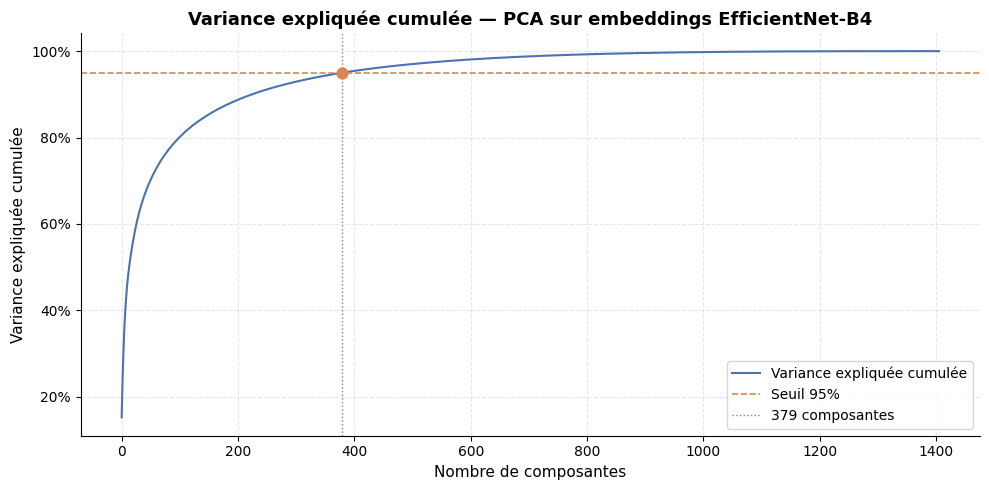

379 dimensions à garder pour conserver 95% de la variance


In [47]:
pcamodel = PCA(n_components=min(X_scaled.shape), random_state=42)
pcamodel.fit(X_scaled)

cumvar = np.cumsum(pcamodel.explained_variance_ratio_)
dim = np.argmax(cumvar > 0.95)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(cumvar, color="#4C72B0", linewidth=1.5, label="Variance expliquée cumulée")
ax.axhline(0.95, color="#DD8452", linewidth=1.2, linestyle="--", label="Seuil 95%")
ax.axvline(dim, color="gray", linewidth=1, linestyle=":", label=f"{dim} composantes")
ax.scatter([dim], [cumvar[dim]], color="#DD8452", zorder=5, s=60)

ax.set_title(f"Variance expliquée cumulée — PCA sur embeddings {modele}", fontsize=13, fontweight="bold")
ax.set_xlabel("Nombre de composantes", fontsize=11)
ax.set_ylabel("Variance expliquée cumulée", fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

print(f"{dim} dimensions à garder pour conserver 95% de la variance")

In [48]:
pcamodel = PCA(n_components=dim)
pcamodel.fit(X_scaled)
X_pca = pcamodel.transform(X_scaled)
X_pca.shape

(1406, 379)

# Clustering

In [49]:
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)

In [50]:
gmm.fit(X_pca)
cluster_labels = gmm.predict(X_pca)

In [51]:
# Add cluster labels back to train_df
train_df = train_df.copy()
train_df["cluster"] = cluster_labels

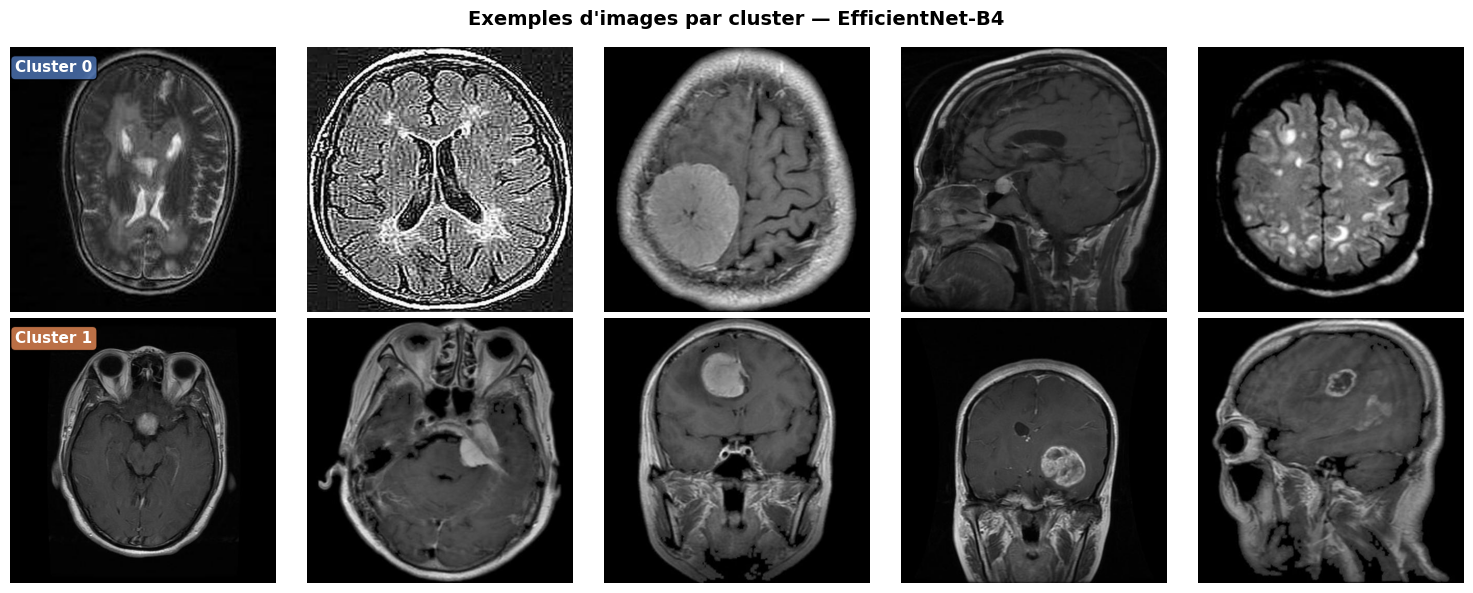

In [52]:
from PIL import Image

CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}
n_samples = 5
clusters = [0, 1]
fig, axes = plt.subplots(len(clusters), n_samples, figsize=(15, 6))
fig.suptitle(f"Exemples d'images par cluster — {modele}", fontsize=14, fontweight="bold")

for row_idx, cluster_id in enumerate(clusters):
    sample_paths = (
        train_df[train_df["cluster"] == cluster_id]["image_path"]
        .sample(n_samples, random_state=21)
        .tolist()
    )
    for col_idx, path in enumerate(sample_paths):
        ax = axes[row_idx][col_idx]
        with Image.open(path) as img:
            ax.imshow(img)
        ax.axis("off")

    axes[row_idx][0].text(
        0.02, 0.95, f"Cluster {cluster_id}",
        transform=axes[row_idx][0].transAxes,
        fontsize=11, fontweight="bold", color="white",
        va="top", ha="left",
        bbox=dict(boxstyle="round,pad=0.3", facecolor=CLUSTER_COLORS[cluster_id], alpha=0.85),
    )

plt.tight_layout()
plt.show()

In [53]:
sil = silhouette_score(X_pca, cluster_labels)
bic = gmm.bic(X_pca)
aic = gmm.aic(X_pca)

print(f"Silhouette : {sil:.4f}  (plus proche de 1 = meilleur)")
print(f"BIC        : {bic:.1f}  (plus bas = meilleur)")
print(f"AIC        : {aic:.1f}  (plus bas = meilleur)")
print(f"Converged  : {gmm.converged_}  (itérations : {gmm.n_iter_})")

Silhouette : 0.1174  (plus proche de 1 = meilleur)
BIC        : 2409283.6  (plus bas = meilleur)
AIC        : 1649410.5  (plus bas = meilleur)
Converged  : True  (itérations : 3)


# Visualisation

In [54]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

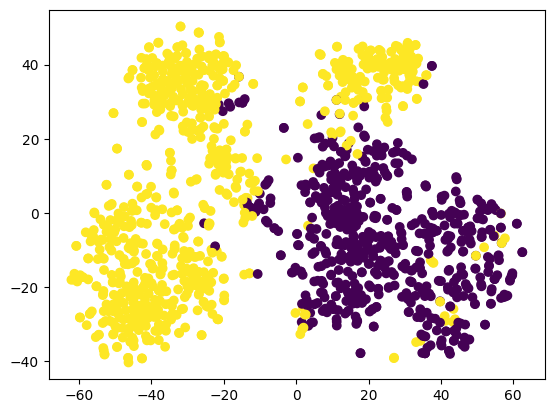

In [55]:
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=cluster_labels)

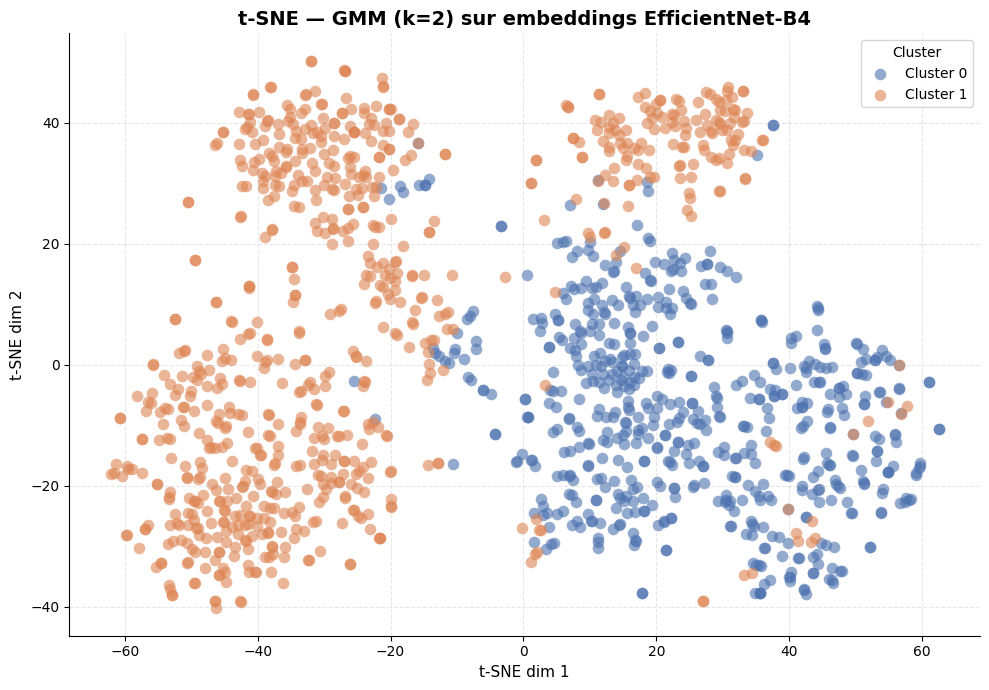

In [56]:
CLUSTER_COLORS = {0: "#4C72B0", 1: "#DD8452"}

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}",
        alpha=0.6, s=70, linewidths=0,
    )

ax.set_title(f"t-SNE — GMM (k=2) sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(title="Cluster", fontsize=10, title_fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

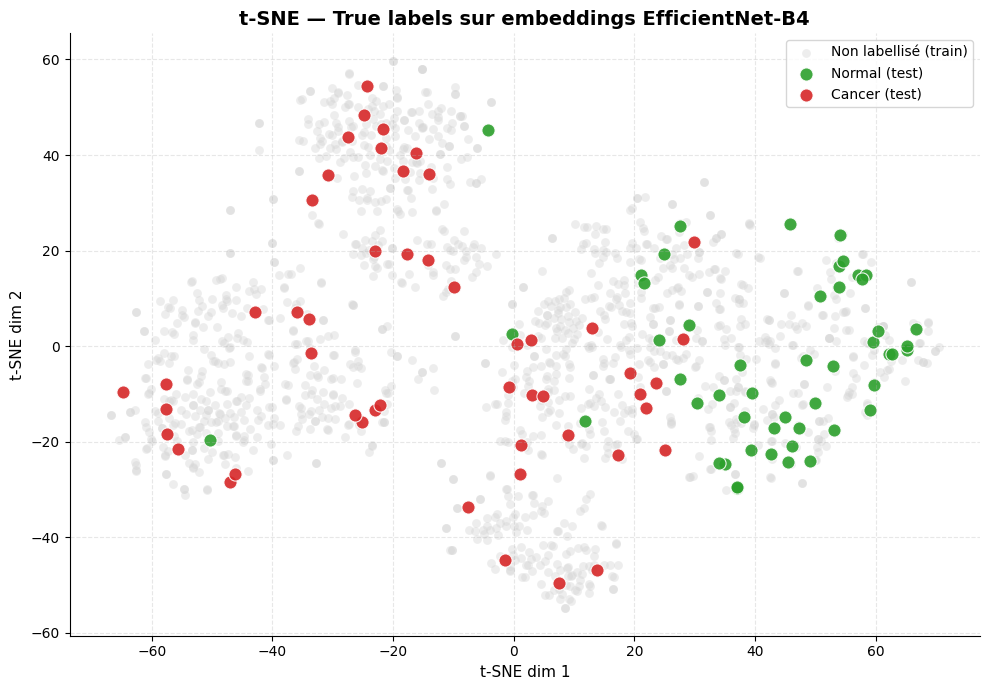

In [57]:
# ── t-SNE avec true labels (train+test combinés) ──────────────────────────
X_test_all     = test_df.drop(columns=["label", "image_path"])
X_test_scaled_ = pd.DataFrame(scaler.transform(X_test_all), columns=X.columns)
X_test_pca_    = pcamodel.transform(X_test_scaled_)

X_combined = np.vstack([X_pca, X_test_pca_])
n_train    = X_pca.shape[0]

tsne_combined = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne_comb   = tsne_combined.fit_transform(X_combined)

X_tsne_train = X_tsne_comb[:n_train]
X_tsne_test  = X_tsne_comb[n_train:]
y_test       = test_df["label"].values  # 0=normal, 1=cancer

LABEL_COLORS = {0: "#2CA02C", 1: "#D62728"}  # vert=normal, rouge=cancer
LABEL_NAMES  = {0: "Normal", 1: "Cancer"}

fig, ax = plt.subplots(figsize=(10, 7))

# Fond : images non labellisées (train)
ax.scatter(
    X_tsne_train[:, 0], X_tsne_train[:, 1],
    c="lightgray", label="Non labellisé (train)",
    alpha=0.4, s=40, linewidths=0,
)

# Superposition : test avec true labels
for lbl, color in LABEL_COLORS.items():
    mask = y_test == lbl
    ax.scatter(
        X_tsne_test[mask, 0], X_tsne_test[mask, 1],
        c=color, label=f"{LABEL_NAMES[lbl]} (test)",
        alpha=0.9, s=90, linewidths=0.8, edgecolors="white",
    )

ax.set_title(f"t-SNE — True labels sur embeddings {modele}", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1", fontsize=11)
ax.set_ylabel("t-SNE dim 2", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()

plt.tight_layout()
plt.show()

# SCORES

Mapping retenu : cluster 0 → normal, cluster 1 → cancer

  Accuracy   : 0.7900
  Precision  : 0.8085  (cancer=positif)
  Recall     : 0.7600  (cancer=positif)
  F1-score   : 0.7835
  F2-score   : 0.7692  (recall x2)
  ARI        : 0.3297

              precision    recall  f1-score   support

      Normal       0.77      0.82      0.80        50
      Cancer       0.81      0.76      0.78        50

    accuracy                           0.79       100
   macro avg       0.79      0.79      0.79       100
weighted avg       0.79      0.79      0.79       100



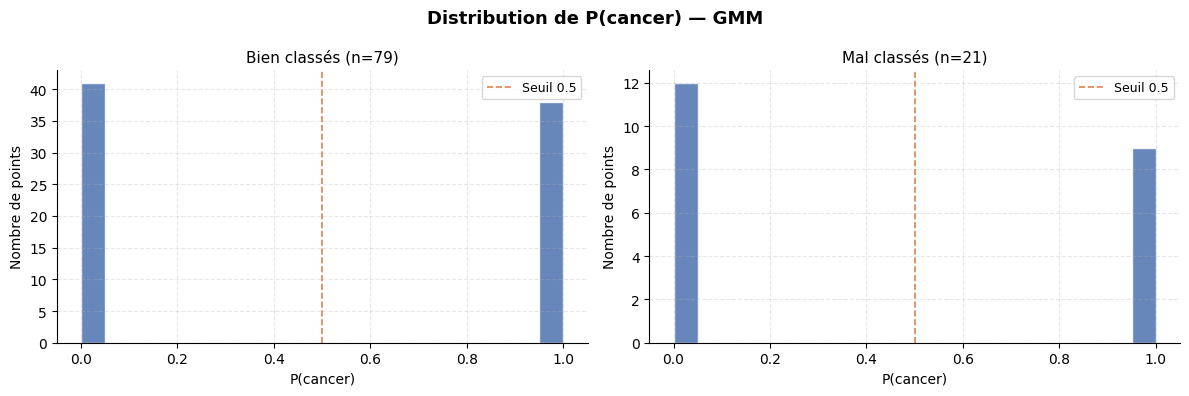

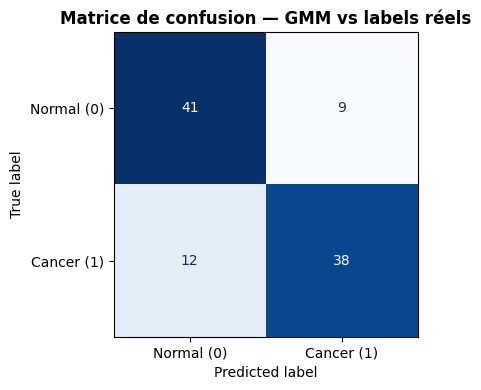

In [58]:
X_test = test_df.drop(columns=["label", "image_path"])
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
X_test_pca = pcamodel.transform(X_test_scaled)
cluster_pred = gmm.predict(X_test_pca)
proba_pred   = gmm.predict_proba(X_test_pca)   # shape (n, 2)
y_true = test_df["label"].values  # 0=normal, 1=cancer

# ── Alignement des labels ──────────────────────────────────────────────────
acc_direct   = (cluster_pred == y_true).mean()
acc_inverted = (1 - cluster_pred == y_true).mean()

if acc_direct >= acc_inverted:
    aligned_pred = cluster_pred
    cluster_to_class = {0: "normal", 1: "cancer"}
else:
    aligned_pred = 1 - cluster_pred
    cluster_to_class = {0: "cancer", 1: "normal"}

cancer_cluster = [c for c, name in cluster_to_class.items() if name == "cancer"][0]
proba_cancer = proba_pred[:, cancer_cluster]  # P(appartenir au cluster cancer)

ari = adjusted_rand_score(y_true, aligned_pred)
print(f"Mapping retenu : cluster 0 → {cluster_to_class[0]}, cluster 1 → {cluster_to_class[1]}\n")

# ── Métriques ──────────────────────────────────────────────────────────────
print("=" * 45)
print(f"  Accuracy   : {accuracy_score(y_true, aligned_pred):.4f}")
print(f"  Precision  : {precision_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  Recall     : {recall_score(y_true, aligned_pred):.4f}  (cancer=positif)")
print(f"  F1-score   : {f1_score(y_true, aligned_pred):.4f}")
print(f"  F2-score   : {fbeta_score(y_true, aligned_pred, beta=2):.4f}  (recall x2)")
print(f"  ARI        : {ari:.4f}")
print("=" * 45)
print()
print(classification_report(y_true, aligned_pred, target_names=["Normal", "Cancer"]))

# ── Distribution des probabilités — bien vs mal classés ───────────────────
correct_mask = aligned_pred == y_true
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Distribution de P(cancer) — GMM", fontsize=13, fontweight="bold")

for ax, (label, mask) in zip(axes, [("Bien classés", correct_mask), ("Mal classés", ~correct_mask)]):
    n = mask.sum()
    ax.hist(proba_cancer[mask], bins=20, range=(0, 1), color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.axvline(0.5, color="#DD8452", linestyle="--", linewidth=1.2, label="Seuil 0.5")
    ax.set_title(f"{label} (n={n})", fontsize=11)
    ax.set_xlabel("P(cancer)", fontsize=10)
    ax.set_ylabel("Nombre de points", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

# ── Matrice de confusion ───────────────────────────────────────────────────
cm = confusion_matrix(y_true, aligned_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal (0)", "Cancer (1)"]).plot(
    ax=ax, colorbar=False, cmap="Blues"
)
ax.set_title("Matrice de confusion — GMM vs labels réels", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Nettoyage des pseudo-labels par régression logistique OOF

Les pseudo-labels GMM sont bruités (~21% d'erreur observée sur le set de test labellisé). Pour les nettoyer avant export :

1. **Pipeline sans leakage** — `StandardScaler` + `PCA` + `LogisticRegression` encapsulés dans un `sklearn.pipeline.Pipeline`. Scaler et PCA sont **re-fittés dans chaque fold** sur les données d'entraînement seulement → le fold de validation ne fuite jamais dans les composantes PCA ni dans les statistiques de scaling.
2. **Entraînement OOF** — `StratifiedKFold(K=5)` sur les 1406 images avec leurs pseudo-labels GMM. Chaque image reçoit une proba prédite par un modèle qui **ne l'a pas vue**.
3. **Filtrage** — on ne garde que les images où la LR est confiante **ET** en accord avec le pseudo-label GMM.

Régularisation forte : `penalty='l2'`, `C=1e-3`, `class_weight='balanced'`. La forte régularisation force la LR à généraliser au lieu de mémoriser les pseudo-labels.

> Le GMM reste fitté globalement sur les 1406 points — c'est un compromis accepté en pseudo-labeling. Fitter le GMM par fold changerait la nature des pseudo-labels à chaque split.

In [59]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline

# ── Pseudo-labels GMM sur les 1406 images non labellisées ─────────────────
pseudo_y = np.array([
    1 if cluster_to_class[c] == "cancer" else 0
    for c in cluster_labels
])

print(f"Pseudo-labels GMM   : {len(pseudo_y)} images")
print(f"  pseudo-cancer (1) : {(pseudo_y == 1).sum()}")
print(f"  pseudo-normal (0) : {(pseudo_y == 0).sum()}")

# ── Leakage-free pipeline : scaler + PCA + LR refitted inside each fold ───
# Feeding RAW features X (1792 dim). StandardScaler and PCA are re-fitted on
# the training fold only at each CV split, so the held-out fold never leaks
# into scaling stats nor PCA components.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca",    PCA(n_components=0.95, random_state=42)),
    ("lr",     LogisticRegression(
        penalty="l2",
        C=1e-3,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=1000,
        random_state=42,
    )),
])

oof_proba = cross_val_predict(
    pipe, X, pseudo_y,
    cv=skf, method="predict_proba", n_jobs=-1,
)[:, 1]  # P(cancer) out-of-fold

print(f"\noof_proba shape  : {oof_proba.shape}")
print(f"oof_proba range  : [{oof_proba.min():.4f}, {oof_proba.max():.4f}]  (mean={oof_proba.mean():.4f})")

Pseudo-labels GMM   : 1406 images
  pseudo-cancer (1) : 787
  pseudo-normal (0) : 619

oof_proba shape  : (1406,)
oof_proba range  : [0.0001, 0.9999]  (mean=0.5526)


## Distribution des probabilités OOF

On visualise la distribution des probas OOF puis on teste plusieurs seuils candidats.
Pour chaque seuil `(LOW, HIGH)` on garde les images où :

- la proba OOF est **hors** de la zone ambiguë `[LOW, HIGH]`
- **ET** la prédiction OOF (argmax) est d'accord avec le pseudo-label GMM

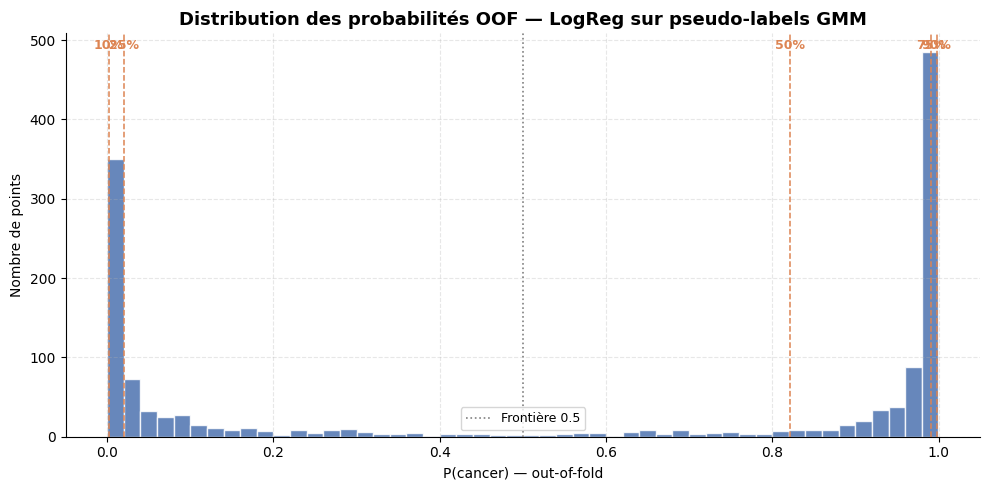


Points conservés par seuil candidat (confiant ET accord avec pseudo-label GMM) :

 seuil_bas  seuil_haut  n_confiants  n_accord pct_conserves
      0.20        0.80         1270      1270         90.3%
      0.25        0.75         1293      1293         92.0%
      0.30        0.70         1326      1325         94.2%
      0.35        0.65         1353      1350         96.0%
      0.40        0.60         1374      1367         97.2%


In [60]:
# ── Histogram of the OOF probability distribution with quantile markers ──
quantile_levels = [0.10, 0.25, 0.50, 0.75, 0.90]
quantiles = np.quantile(oof_proba, quantile_levels)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(oof_proba, bins=50, color="#4C72B0", edgecolor="white", alpha=0.85)

ymax = ax.get_ylim()[1]
for q, level in zip(quantiles, quantile_levels):
    ax.axvline(q, color="#DD8452", linestyle="--", linewidth=1.1)
    ax.text(q, ymax * 0.96, f"{int(level*100)}%", ha="center", fontsize=9,
            color="#DD8452", fontweight="bold")

ax.axvline(0.5, color="gray", linestyle=":", linewidth=1.2, label="Frontière 0.5")
ax.set_title("Distribution des probabilités OOF — LogReg sur pseudo-labels GMM",
             fontsize=13, fontweight="bold")
ax.set_xlabel("P(cancer) — out-of-fold")
ax.set_ylabel("Nombre de points")
ax.legend(fontsize=9)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# ── Candidate thresholds : confident AND agreeing with GMM pseudo-label ──
oof_pred = (oof_proba >= 0.5).astype(int)
candidates = [(0.2, 0.8), (0.25, 0.75), (0.3, 0.7), (0.35, 0.65), (0.4, 0.6)]
rows = []
for low, high in candidates:
    confident_mask = (oof_proba <= low) | (oof_proba >= high)
    agree_mask = confident_mask & (oof_pred == pseudo_y)
    rows.append({
        "seuil_bas"    : low,
        "seuil_haut"   : high,
        "n_confiants"  : int(confident_mask.sum()),
        "n_accord"     : int(agree_mask.sum()),
        "pct_conserves": f"{agree_mask.mean():.1%}",
    })
seuils_df = pd.DataFrame(rows)
print("\nPoints conservés par seuil candidat (confiant ET accord avec pseudo-label GMM) :\n")
print(seuils_df.to_string(index=False))

# Extractions

On applique le seuil choisi et on exporte :

- `pseudo_labels_lr_oof.csv` — pseudo-labels nettoyés par OOF sur les 1406 images non labellisées
- `true_labels_test.csv` — vrais labels du set de test (100 images labellisées)

> Ajuster `LOW` / `HIGH` ci-dessous après inspection de l'histogramme et du tableau des candidats.

In [61]:
# ── Apply the chosen threshold ────────────────────────────────────────────
LOW, HIGH = 0.2, 0.8  # adjust after inspecting the histogram + candidate table

oof_pred = (oof_proba >= 0.5).astype(int)
confident_mask = (oof_proba <= LOW) | (oof_proba >= HIGH)
agree_mask = confident_mask & (oof_pred == pseudo_y)

# ── Build the cleaned pseudo-label DataFrame ──────────────────────────────
clean_df = pd.DataFrame({
    "image_path"      : train_df["image_path"].values,
    "label"           : pseudo_y,
    "oof_proba_cancer": oof_proba.round(4),
    "oof_pred"        : oof_pred,
})

n_total = len(clean_df)
clean_df = clean_df.loc[agree_mask].reset_index(drop=True)
n_kept = len(clean_df)

print(f"Seuils appliqués : LOW={LOW} / HIGH={HIGH}")
print(f"Total initial    : {n_total}")
print(f"Conservés        : {n_kept}  ({n_kept/n_total:.1%})")
print(f"  pseudo-cancer (1) : {(clean_df['label'] == 1).sum()}")
print(f"  pseudo-normal (0) : {(clean_df['label'] == 0).sum()}\n")

out_path = Path("pseudo_labels_gmm_v3.csv")
clean_df.to_csv(out_path, index=False)
print(f"Sauvegardé → {out_path}")

clean_df.head(10)

Seuils appliqués : LOW=0.2 / HIGH=0.8
Total initial    : 1406
Conservés        : 1270  (90.3%)
  pseudo-cancer (1) : 711
  pseudo-normal (0) : 559

Sauvegardé → pseudo_labels_gmm_v3.csv


,image_path,label,oof_proba_cancer,oof_pred
0,data\sans_label\001b158a-7af8-451e-bf31-3a9116...,1,0.9805,1
1,data\sans_label\00366e8d-5520-4d3c-a70b-91a7ee...,0,0.1102,0
2,data\sans_label\00455a62-f79f-4072-9a23-4951e7...,0,0.0012,0
3,data\sans_label\005d9a37-8894-4eb5-8367-1015d4...,1,0.9958,1
4,data\sans_label\009e9d31-9f37-4d97-a941-815012...,1,0.8947,1
5,data\sans_label\009eac4a-c951-4da9-852a-b32e9c...,1,0.9965,1
6,data\sans_label\00e9e198-79de-47ab-9f4e-7b7615...,1,0.9994,1
7,data\sans_label\01717fbf-4bcf-475a-a718-361ed0...,1,0.8186,1
8,data\sans_label\01d1f0ed-5070-45a8-ad26-f8a95e...,0,0.0002,0
9,data\sans_label\01d4471e-7c83-4335-ab49-c650d0...,1,0.9979,1


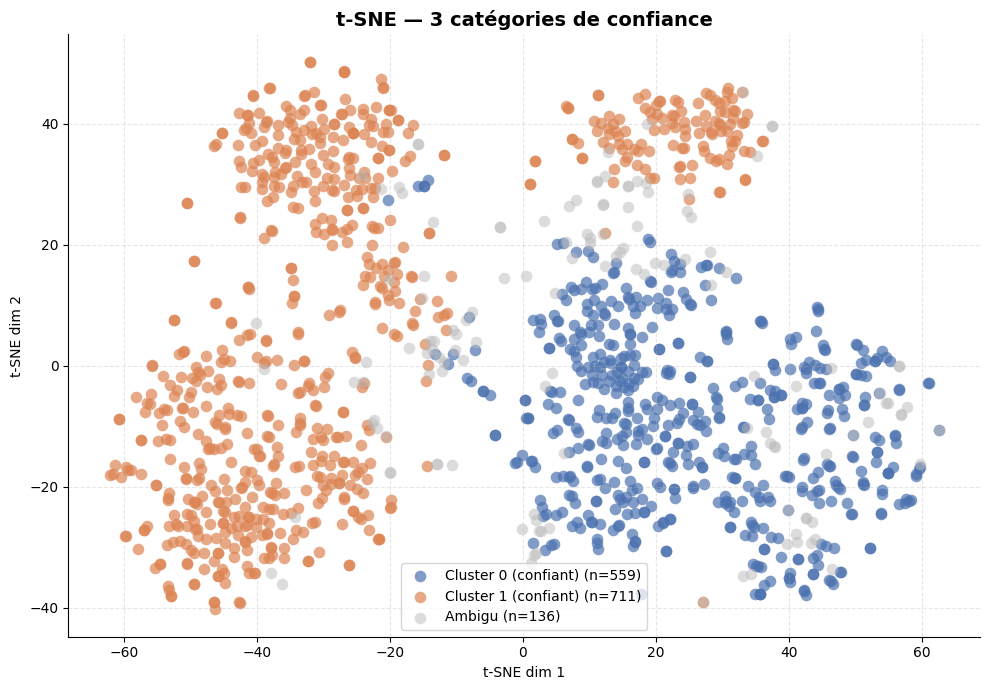

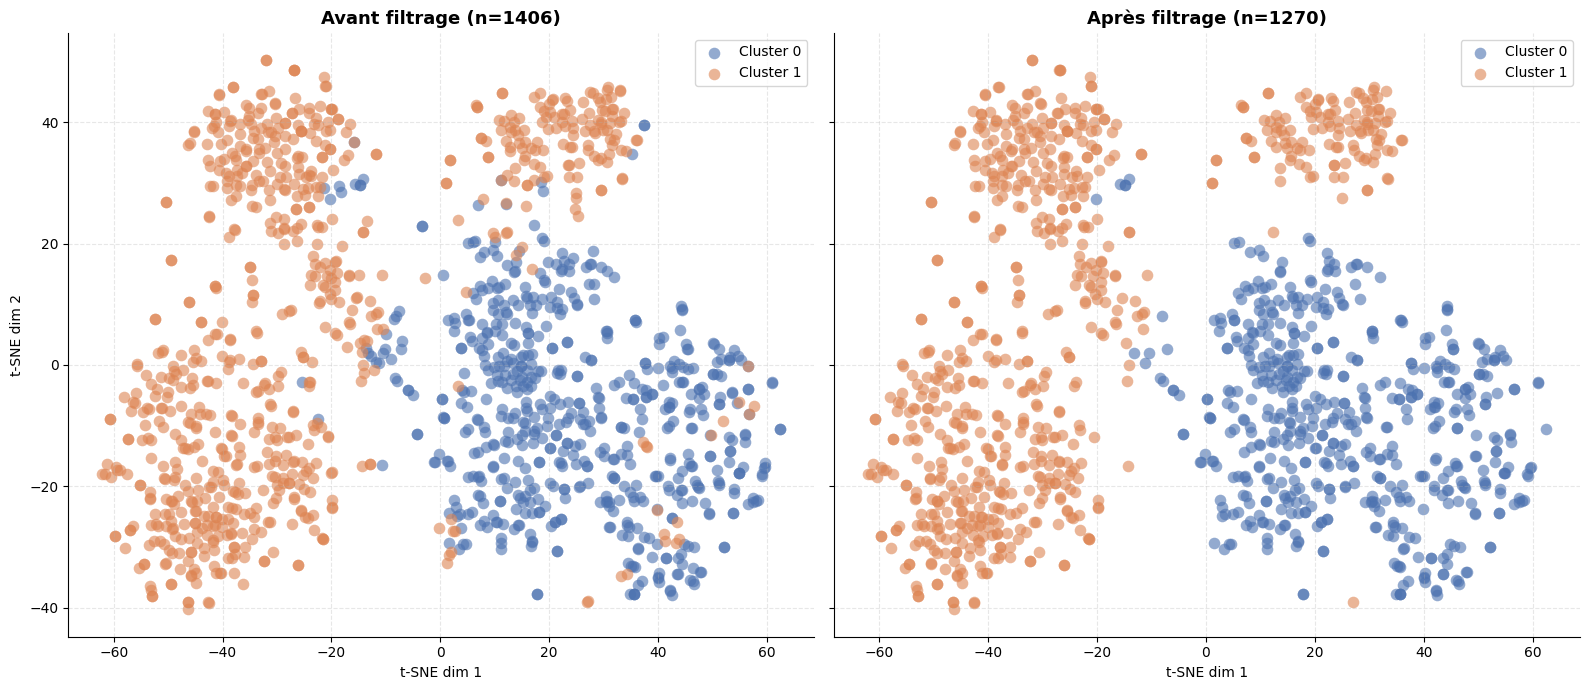

In [62]:
# ── Build confidence categories from OOF LR agreement with GMM clusters ──
is_confident = agree_mask
confidence_category = np.full(len(cluster_labels), "ambigu", dtype=object)
confidence_category[is_confident & (cluster_labels == 0)] = "cluster_0_confiant"
confidence_category[is_confident & (cluster_labels == 1)] = "cluster_1_confiant"

# ── Plot 1 : t-SNE with 3 confidence categories on a single plot ──────────
CATEGORY_STYLES = {
    "cluster_0_confiant": {"color": CLUSTER_COLORS[0], "label": "Cluster 0 (confiant)", "alpha": 0.7},
    "cluster_1_confiant": {"color": CLUSTER_COLORS[1], "label": "Cluster 1 (confiant)", "alpha": 0.7},
    "ambigu":             {"color": "#BBBBBB",         "label": "Ambigu",               "alpha": 0.5},
}

fig, ax = plt.subplots(figsize=(10, 7))
for category, style in CATEGORY_STYLES.items():
    mask = confidence_category == category
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=style["color"], label=f'{style["label"]} (n={mask.sum()})',
        alpha=style["alpha"], s=70, linewidths=0,
    )
ax.set_title("t-SNE — 3 catégories de confiance", fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dim 1")
ax.set_ylabel("t-SNE dim 2")
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.3)
sns.despine()
plt.tight_layout()
plt.show()

# ── Plot 2 : side-by-side comparison — original vs filtered ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharex=True, sharey=True)

# Left : original t-SNE, all points colored by cluster
for cluster_id, color in CLUSTER_COLORS.items():
    mask = cluster_labels == cluster_id
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}", alpha=0.6, s=70, linewidths=0,
    )
axes[0].set_title(f"Avant filtrage (n={len(cluster_labels)})", fontsize=13, fontweight="bold")
axes[0].set_xlabel("t-SNE dim 1")
axes[0].set_ylabel("t-SNE dim 2")
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle="--", alpha=0.3)

# Right : filtered t-SNE, confident points only
for cluster_id, color in CLUSTER_COLORS.items():
    mask = (cluster_labels == cluster_id) & is_confident
    axes[1].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=f"Cluster {cluster_id}", alpha=0.6, s=70, linewidths=0,
    )
axes[1].set_title(f"Après filtrage (n={int(is_confident.sum())})", fontsize=13, fontweight="bold")
axes[1].set_xlabel("t-SNE dim 1")
axes[1].legend(fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.3)

sns.despine()
plt.tight_layout()
plt.show()

In [63]:
# ── Test set with true labels ─────────────────────────────────────────────
test_export_df = pd.DataFrame({
    "image_path"   : test_df["image_path"].values,
    "label"        : test_df["label"].values,   # vrais labels : 1=cancer, 0=normal
    "proba_cancer" : proba_pred[:, cancer_cluster].round(4),
    "proba_normal" : proba_pred[:, 1 - cancer_cluster].round(4),
})

print(f"Total : {len(test_export_df)} images")
print(f"  cancer (1) : {(test_export_df['label'] == 1).sum()}")
print(f"  normal (0) : {(test_export_df['label'] == 0).sum()}\n")

out_path_test = Path("true_labels_test.csv")
test_export_df.to_csv(out_path_test, index=False)
print(f"Sauvegardé → {out_path_test}")

test_export_df.head(10)

Total : 100 images
  cancer (1) : 50
  normal (0) : 50

Sauvegardé → true_labels_test.csv


,image_path,label,proba_cancer,proba_normal
0,data\avec_labels\cancer\05340cd4-3bb2-459d-993...,1,1.0,0.0
1,data\avec_labels\cancer\0c6f3641-60d9-4a76-abe...,1,0.0,1.0
2,data\avec_labels\cancer\0f718241-8f63-4b55-81c...,1,1.0,0.0
3,data\avec_labels\cancer\11a7a426-4806-401e-98b...,1,1.0,0.0
4,data\avec_labels\cancer\1c043dbb-4623-4769-8e5...,1,1.0,0.0
5,data\avec_labels\cancer\27149ff6-8363-4942-a72...,1,1.0,0.0
6,data\avec_labels\cancer\2b810835-844c-49ff-b0f...,1,1.0,0.0
7,data\avec_labels\cancer\2d662cc1-509b-4657-a20...,1,1.0,0.0
8,data\avec_labels\cancer\2fa551e9-5b85-44f6-ab7...,1,1.0,0.0
9,data\avec_labels\cancer\3c3d07cb-ec2a-43b0-b8a...,1,1.0,0.0
